In [ ]:
from google.colab import files
uploaded=files.upload()


Saving Daily_Cal_Req.csv to Daily_Cal_Req.csv


In [ ]:
import pandas as pd
df=pd.read_csv('Daily_Cal_Req.csv')
print(df.head())


    Age  Gender  Height_cm  Weight_kg Activity_Level  Sleep_Hours  \
0  58.0    Male      151.0       80.0          Light          5.6   
1  46.0  Female      150.0       65.0         Active          6.2   
2  53.0  Female      190.0       91.0    Very Active          5.5   
3  60.0  Female      154.0       66.0    Very Active          8.1   
4  35.0    Male      163.0       85.0          Light          7.8   

   Water_Intake_L      Goal Diet_Type  Daily_Calorie_Requirement  
0             3.6      Gain       Veg                       2306  
1             1.5  Maintain       Veg                       2064  
2             1.2      Gain   Non-Veg                       3476  
3             1.6      Gain     Vegan                       2207  
4             2.4      Gain      Jain                       2636  


In [ ]:
df.isnull().sum()

,0
Age,25
Gender,25
Height_cm,0
Weight_kg,0
Activity_Level,0
Sleep_Hours,0
Water_Intake_L,0
Goal,0
Diet_Type,0
Daily_Calorie_Requirement,0


In [ ]:
!pip install missingno

In [ ]:
diet_type_counts = df['Diet_Type'].value_counts()
most_preferred_diet = diet_type_counts.idxmax()

print("Diet Type Distribution:")
print(diet_type_counts)
print(f"\nMost Preferred Diet Type: {most_preferred_diet}")

Diet Type Distribution:
Diet_Type
Veg        87
Vegan      61
Non-Veg    51
Jain       51
Name: count, dtype: int64

Most Preferred Diet Type: Veg


In [ ]:
activity_level_counts = df['Activity_Level'].value_counts()
most_common_activity = activity_level_counts.idxmax()

print("Activity Level Distribution:")
print(activity_level_counts)
print(f"\nMost Common Activity Level: {most_common_activity}")

Activity Level Distribution:
Activity_Level
Light          66
Very Active    50
Sedentary      45
Moderate       45
Active         44
Name: count, dtype: int64

Most Common Activity Level: Light


In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
age_bins = [0, 18, 35, 50, 65, 100]
age_labels = ['0-18', '19-35', '36-50', '51-65', '66+']

df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

age_group_counts = df['Age_Group'].value_counts().sort_index()
predominant_age_group = age_group_counts.idxmax()

print("Age Group Distribution:")
print(age_group_counts)
print(f"\nPredominant Age Group: {predominant_age_group}")

Age Group Distribution:
Age_Group
0-18       0
19-35     78
36-50    111
51-65     61
66+        0
Name: count, dtype: int64

Predominant Age Group: 36-50


/tmp/ipykernel_2921/887652526.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [ ]:
gender_counts = df['Gender'].value_counts()

print("Gender Distribution:")
print(gender_counts)

if 'Male' in gender_counts and 'Female' in gender_counts:
    male_female_ratio = gender_counts['Male'] / gender_counts['Female']
    print(f"\nRatio of Male to Female Participants: {male_female_ratio:.2f}")
elif 'Male' in gender_counts:
    print("\nOnly Male participants found.")
elif 'Female' in gender_counts:
    print("\nOnly Female participants found.")
else:
    print("\nNo Male or Female participants found.")

Gender Distribution:
Gender
Male      131
Female     94
Name: count, dtype: int64

Ratio of Male to Female Participants: 1.39


In [ ]:
calorie_intake_by_goal = df.groupby('Goal')['Daily_Calorie_Requirement'].mean().sort_values(ascending=False)

highest_calorie_goal = calorie_intake_by_goal.idxmax()
highest_calorie_value = calorie_intake_by_goal.max()

print("Average Daily Calorie Requirement by Goal:")
print(calorie_intake_by_goal)
print(f"\nGoal requiring the highest calorie intake: {highest_calorie_goal} with an average of {highest_calorie_value:.2f} calories.")

Average Daily Calorie Requirement by Goal:
Goal
Gain        2615.526786
Maintain    2436.463768
Lose        2240.000000
Name: Daily_Calorie_Requirement, dtype: float64

Goal requiring the highest calorie intake: Gain with an average of 2615.53 calories.


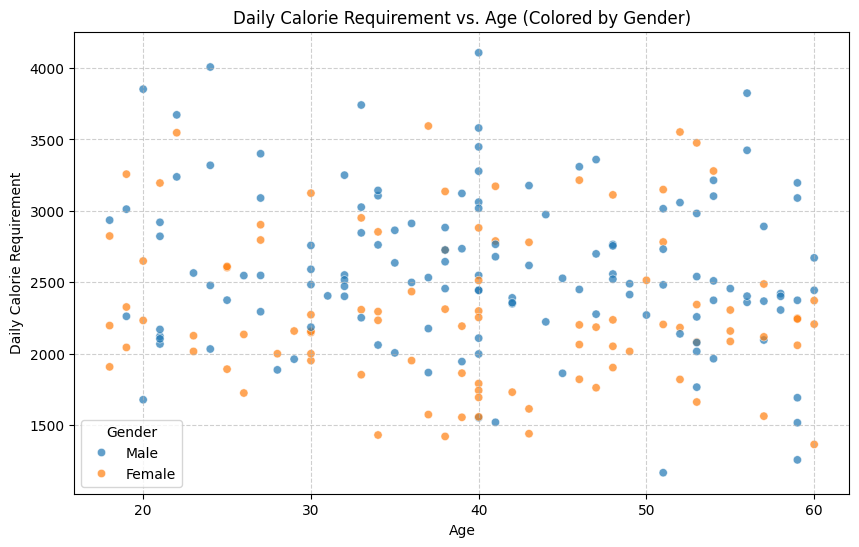

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Daily_Calorie_Requirement', data=df, hue='Gender', alpha=0.7)
plt.title('Daily Calorie Requirement vs. Age (Colored by Gender)')
plt.xlabel('Age')
plt.ylabel('Daily Calorie Requirement')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

yes, calorie reqirement is affected by age, we can verify it using plot.

Average Daily Calorie Requirement by Age Group:
Age_Group
0-18             NaN
19-35    2546.653846
36-50    2431.099099
51-65    2411.868852
66+              NaN
Name: Daily_Calorie_Requirement, dtype: float64


/tmp/ipykernel_2921/506920952.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calorie_by_age_group = df.groupby('Age_Group')['Daily_Calorie_Requirement'].mean()
/tmp/ipykernel_2921/506920952.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calorie_by_age_group.index, y=calorie_by_age_group.values, palette='viridis')


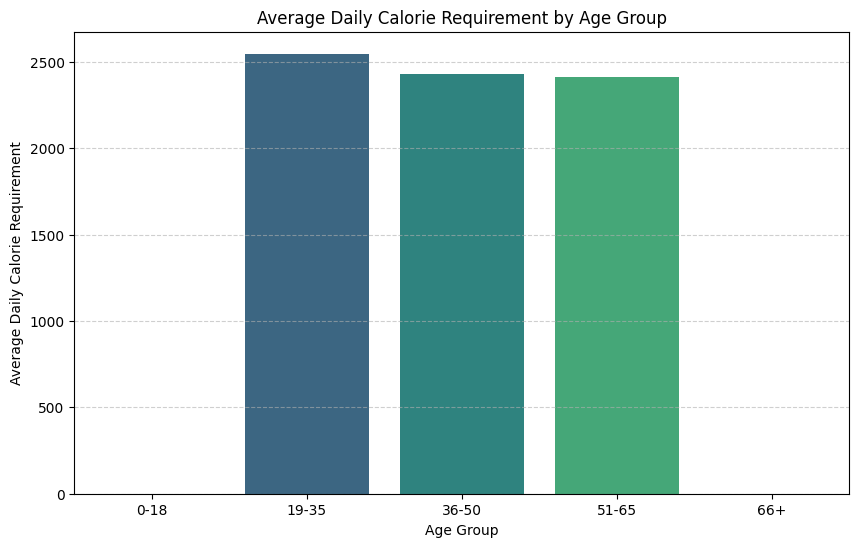

In [ ]:
calorie_by_age_group = df.groupby('Age_Group')['Daily_Calorie_Requirement'].mean()
print("Average Daily Calorie Requirement by Age Group:")
print(calorie_by_age_group)

plt.figure(figsize=(10, 6))
sns.barplot(x=calorie_by_age_group.index, y=calorie_by_age_group.values, palette='viridis')
plt.title('Average Daily Calorie Requirement by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Daily Calorie Requirement')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_2921/942234914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_Level', y='Water_Intake_L', data=df, palette='Set2')


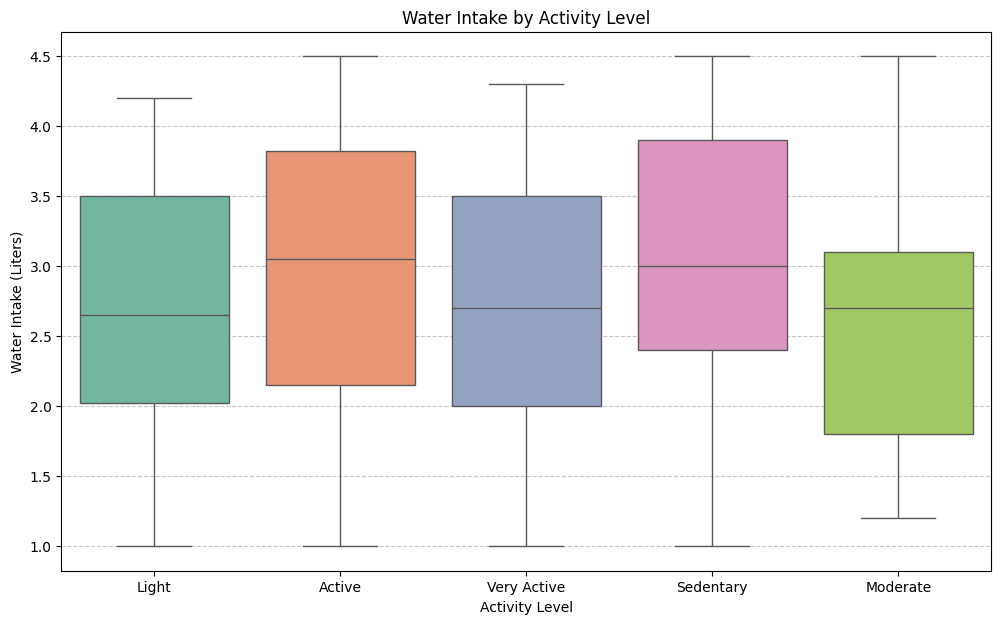

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Activity_Level', y='Water_Intake_L', data=df, palette='Set2')
plt.title('Water Intake by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Water Intake (Liters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

given above is the relation between water intake and activity level


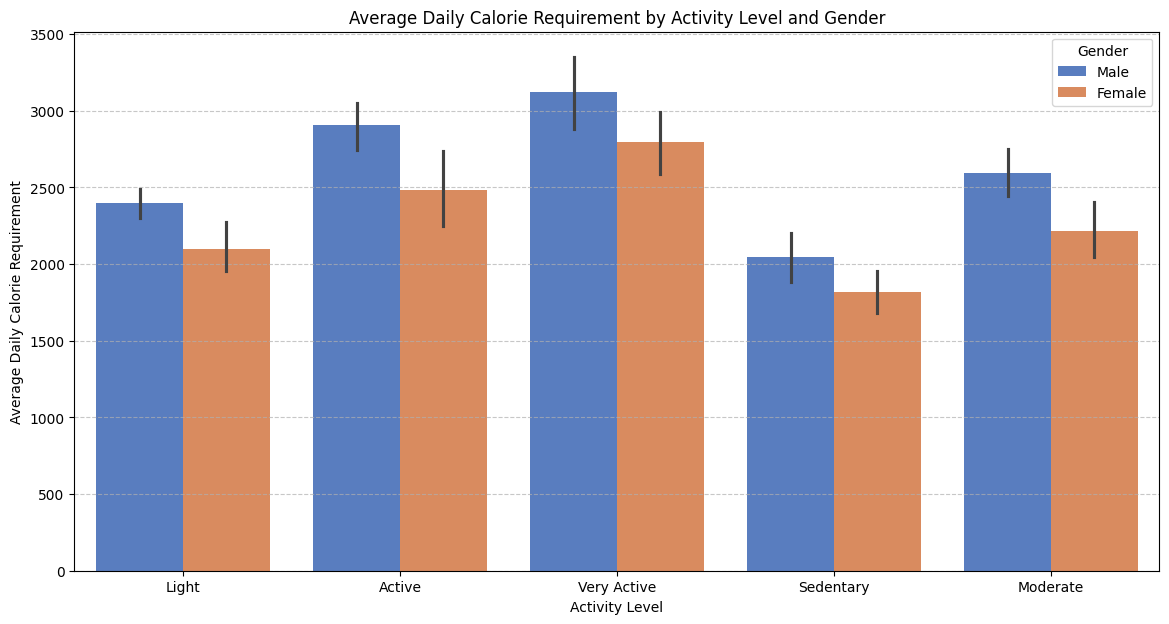

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Activity_Level', y='Daily_Calorie_Requirement', hue='Gender', data=df, palette='muted')
plt.title('Average Daily Calorie Requirement by Activity Level and Gender')
plt.xlabel('Activity Level')
plt.ylabel('Average Daily Calorie Requirement')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.show()

In [ ]:
calorie_by_activity_gender = df.groupby(['Activity_Level', 'Gender'])['Daily_Calorie_Requirement'].mean().unstack()
print("Average Daily Calorie Requirement by Activity Level and Gender:")
print(calorie_by_activity_gender)

Average Daily Calorie Requirement by Activity Level and Gender:
Gender               Female         Male
Activity_Level                          
Active          2483.857143  2906.083333
Light           2100.909091  2399.743590
Moderate        2213.294118  2593.500000
Sedentary       1816.176471  2049.217391
Very Active     2795.166667  3125.478261


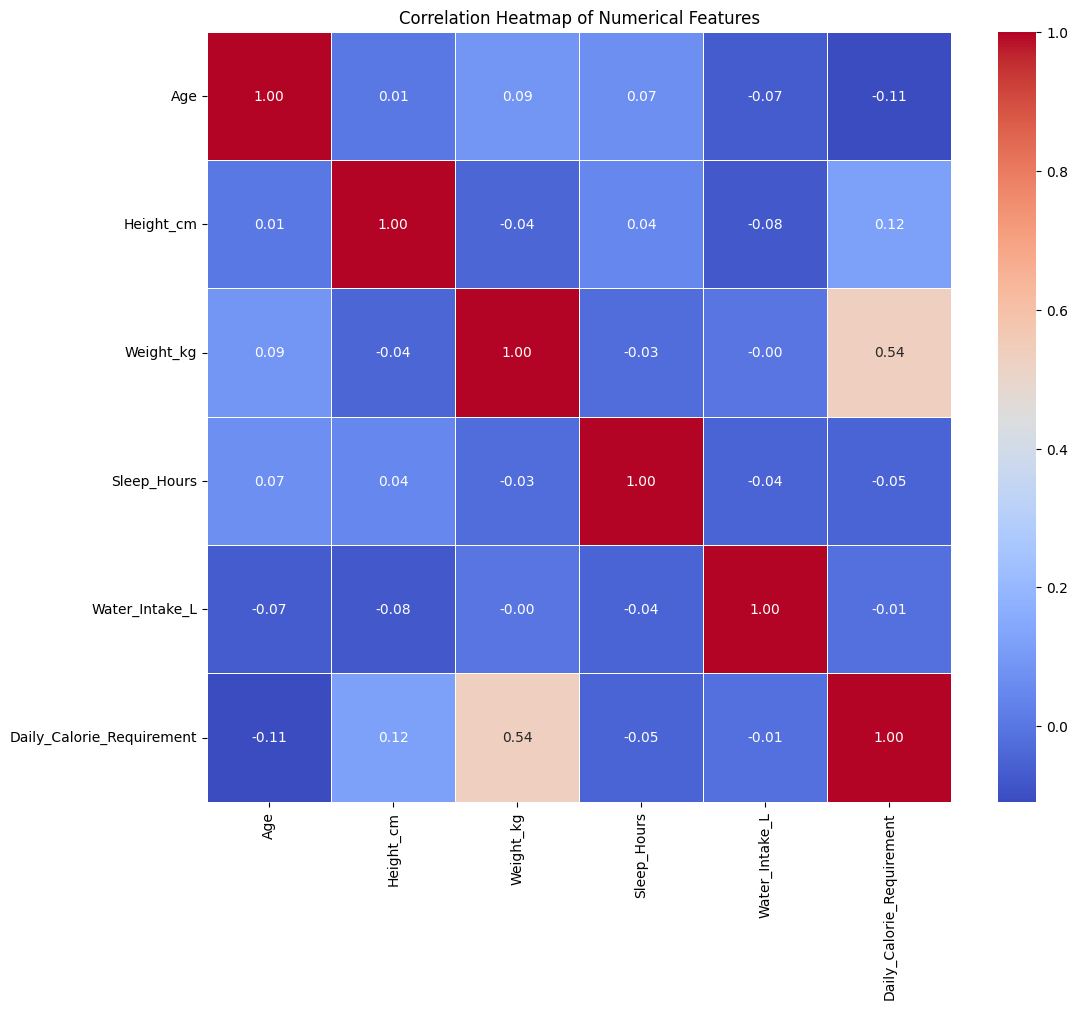

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

the correlation heatmap is displayed above


In [ ]:
import plotly.express as px

# Prepare data for the treemap: count participants within each combination of Goal, Activity_Level, and Diet_Type
treemap_data = df.groupby(['Goal', 'Activity_Level', 'Diet_Type']).size().reset_index(name='Count')

# Create the treemap
fig = px.treemap(treemap_data,
                 path=['Goal', 'Activity_Level', 'Diet_Type'],
                 values='Count',
                 title='Distribution of Participants by Goal, Activity Level, and Diet Type')

fig.show()

distribution of participants by goals, activity leven and diet type

In [ ]:
import plotly.express as px

# Prepare data for the sunburst chart: count participants within each combination of Goal, Activity_Level, and Diet_Type
# This is the same data preparation as for the treemap, as both visualizations use hierarchical data.
sunburst_data = df.groupby(['Goal', 'Activity_Level', 'Diet_Type']).size().reset_index(name='Count')

# Create the sunburst chart
fig = px.sunburst(sunburst_data,
                  path=['Goal', 'Activity_Level', 'Diet_Type'],
                  values='Count',
                  title='Distribution of Participants by Goal, Activity Level, and Diet Type')

fig.show()

Sunburst Chart with Goal, Activity_Level, Diet_Type

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_samples = 500

data = {
    'age': np.random.randint(18, 65, num_samples),
    'bmi': np.random.uniform(18, 40, num_samples),
    'children': np.random.randint(0, 4, num_samples),
    'smoker': np.random.choice(['yes', 'no'], num_samples, p=[0.2, 0.8]),
    'region': np.random.choice(['northwest', 'northeast', 'southwest', 'southeast'], num_samples),
    'charges': np.random.uniform(1000, 30000, num_samples) # Base charges
}

df_charges = pd.DataFrame(data)

# Introduce some correlations to make the data more realistic
df_charges['charges'] = df_charges['charges'] + \
                         df_charges['age'] * 100 + \
                         df_charges['bmi'] * 50 + \
                         df_charges['children'] * 500

df_charges.loc[df_charges['smoker'] == 'yes', 'charges'] = df_charges.loc[df_charges['smoker'] == 'yes', 'charges'] * 2.5

# Add some noise
df_charges['charges'] = df_charges['charges'] + np.random.normal(0, 1000, num_samples)

df_charges['charges'] = np.maximum(100, df_charges['charges']) # Ensure charges are not negative

print("Synthetic Medical Charges Dataset Head:")
display(df_charges.head())
print("Synthetic Medical Charges Dataset Info:")
display(df_charges.info())


Synthetic Medical Charges Dataset Head:


,age,bmi,children,smoker,region,charges
0,56,28.081564,1,no,northeast,13520.974983
1,46,30.003569,1,no,southeast,21524.110071
2,32,38.712226,3,no,northwest,35642.308828
3,60,26.494258,0,no,northeast,35601.811731
4,25,39.146192,1,yes,southwest,18183.226288


Synthetic Medical Charges Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       500 non-null    int64  
 1   bmi       500 non-null    float64
 2   children  500 non-null    int64  
 3   smoker    500 non-null    object 
 4   region    500 non-null    object 
 5   charges   500 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 23.6+ KB


None

### Data Preprocessing: Handling Categorical Variables and Splitting Data

In [ ]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df_charges, columns=['smoker', 'region'], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (400, 7)
Shape of X_test: (100, 7)
Shape of y_train: (400,)
Shape of y_test: (100,)


### Training the Linear Regression Model

In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Model training complete.
Model coefficients: [ 1.34910842e+02  2.85907159e+01  7.64495838e+02  2.89330233e+04
 -3.41424962e+02  3.86183990e+02 -1.35356170e+02]
Model intercept: 14448.907808553478


### Visualizing Targets and Predictions

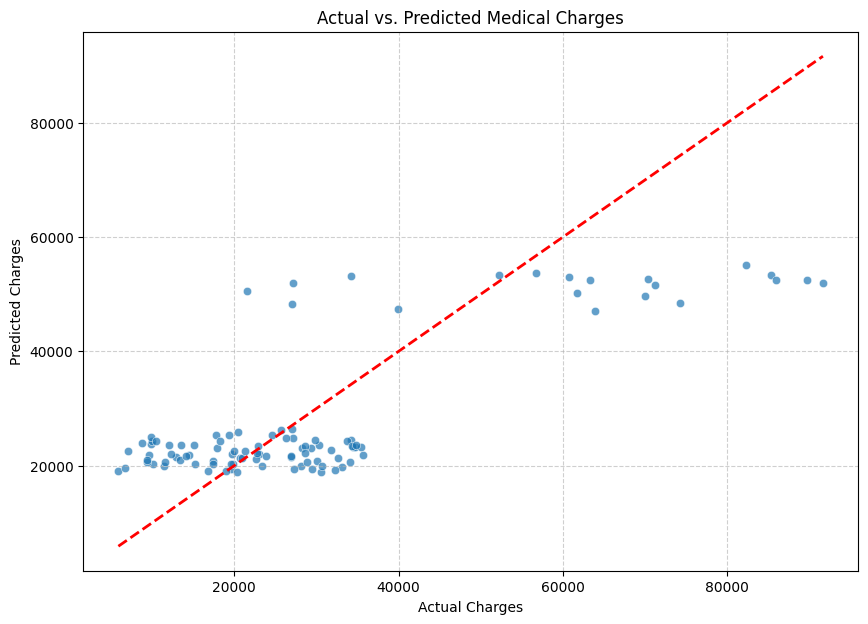

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a scatter plot of actual vs. predicted charges
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted Medical Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Computing the Loss (Evaluation Metrics)

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 9841.83
Mean Squared Error (MSE): 164370688.09
Root Mean Squared Error (RMSE): 12820.71
R-squared (R2 Score): 0.59
